# Paleo Waifu — Battle Balance Analysis

Visualizations for tuning the 3v3 team battle system. Reads CSV data from `tools/battle-sim/dist/`.

```bash
pnpm sim:csv   # generate CSVs into tools/battle-sim/dist/
```

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../tools/battle-sim/dist')

RARITY_ORDER = ['common', 'uncommon', 'rare', 'epic', 'legendary']
ROLE_ORDER = ['striker', 'tank', 'scout', 'support', 'bruiser', 'specialist']

RARITY_COLORS = {
    'common': '#9CA3AF',
    'uncommon': '#22C55E',
    'rare': '#06B6D4',
    'epic': '#A855F7',
    'legendary': '#F59E0B',
}

ROLE_COLORS = {
    'striker': '#EF4444',
    'tank': '#3B82F6',
    'scout': '#22C55E',
    'support': '#EAB308',
    'bruiser': '#A855F7',
    'specialist': '#06B6D4',
}

def balance_band(ax, lo=45, hi=55, color='green', alpha=0.08):
    ax.axhspan(lo, hi, color=color, alpha=alpha, zorder=0)
    ax.axhline(50, color='gray', ls='--', lw=0.8, alpha=0.5)

def balance_band_h(ax, lo=45, hi=55, color='green', alpha=0.08):
    ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0)
    ax.axvline(50, color='gray', ls='--', lw=0.8, alpha=0.5)

In [23]:
# Load CSVs
matchup = pd.read_csv(DATA_DIR / 'matchup.csv')
role = pd.read_csv(DATA_DIR / 'role.csv')
team = pd.read_csv(DATA_DIR / 'team.csv')
ability = pd.read_csv(DATA_DIR / 'ability.csv')

# Clean column names
for df in [matchup, role, team, ability]:
    df.columns = df.columns.str.strip()

# Derived columns
matchup['total_stats'] = matchup['hp'] + matchup['atk'] + matchup['def'] + matchup['spd'] + matchup['abl']
matchup['rarity'] = pd.Categorical(matchup['rarity'], categories=RARITY_ORDER, ordered=True)

print(f'matchup: {matchup.shape[0]} creatures')
print(f'role:    {role.shape[0]} pairs')
print(f'team:    {team.shape[0]} entries')
print(f'ability: {ability.shape[0]} abilities')
matchup.head(3)

matchup: 415 creatures
role:    36 pairs
team:    62 entries
ability: 49 abilities


,name,rarity,role,type,diet,era,hp,atk,def,spd,abl,active1,active2,passive,win_rate,wins,losses,total,total_stats
0,Titanoboa,legendary,scout,Squamata,Unknown,Paleogene,44,80,31,89,63,constrict,ambush,apex_predator,99.51,41197,203,41400,307
1,Protarchaeopteryx,legendary,scout,small theropod,Carnivorous,Cretaceous,46,75,27,87,64,dive_attack,claw_strike,apex_predator,99.18,41061,339,41400,299
2,Archaeopteryx,legendary,scout,small theropod,Carnivorous,Jurassic,46,77,32,87,57,ambush,claw_strike,apex_predator,99.16,41051,349,41400,299


---
## 1. Rarity Power Curve

Higher-rarity creatures should be stronger, but not oppressively so. Look for:
- Distinct but overlapping bands per tier
- Consistent gaps between adjacent tiers
- Tight spread within a tier (low intra-tier variance)

/var/folders/jm/xd38z5j951vdtrlbhnx7fcph0000gn/T/ipykernel_85341/3469333443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=matchup, x='rarity', y='win_rate', order=RARITY_ORDER,


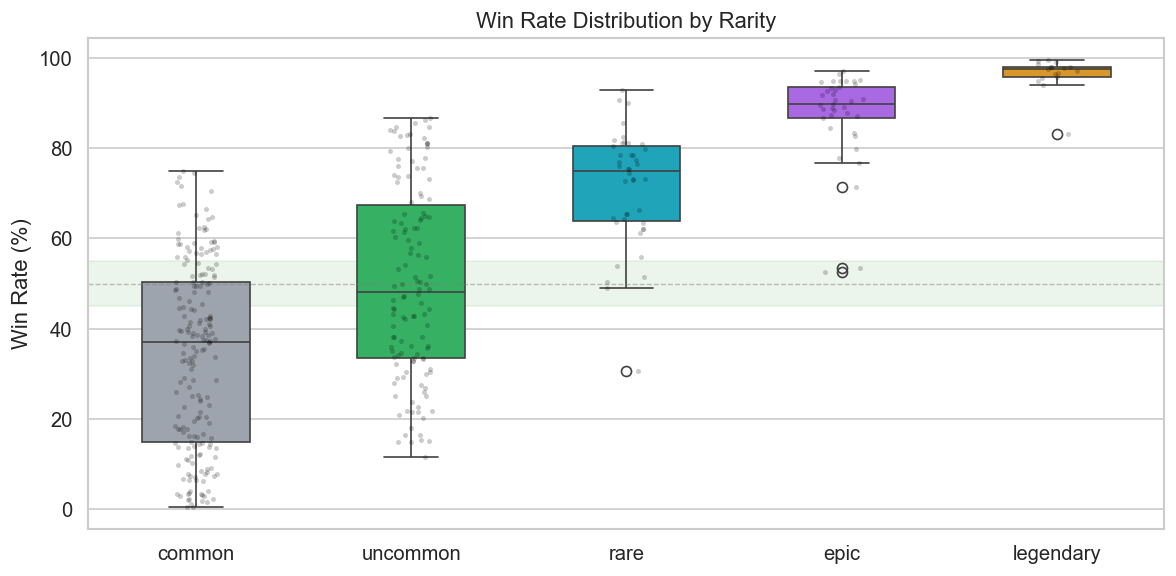

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=matchup, x='rarity', y='win_rate', order=RARITY_ORDER,
            palette=RARITY_COLORS, width=0.5, ax=ax)
sns.stripplot(data=matchup, x='rarity', y='win_rate', order=RARITY_ORDER,
              color='black', alpha=0.2, size=3, jitter=True, ax=ax)
balance_band(ax)
ax.set_title('Win Rate Distribution by Rarity')
ax.set_ylabel('Win Rate (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [25]:
# Rarity summary statistics
rarity_stats = matchup.groupby('rarity', observed=True)['win_rate'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

# Power gap between adjacent tiers
means = rarity_stats['mean']
gaps = means.diff().dropna()
rarity_stats['gap_from_prev'] = gaps

print('RARITY TIER STATISTICS')
print('=' * 60)
display(rarity_stats)
print()
print('BALANCE FLAGS:')
if means.get('legendary', 0) - means.get('common', 0) > 70:
    print(f'  ⚠ Legendary-Common gap is {means["legendary"] - means["common"]:.1f}pp — may be too extreme')
for r in RARITY_ORDER:
    std = rarity_stats.loc[r, 'std'] if r in rarity_stats.index else 0
    if std > 20:
        print(f'  ⚠ {r} has high intra-tier variance (std={std:.1f})')

RARITY TIER STATISTICS


,count,mean,median,std,min,max,gap_from_prev
rarity,,,,,,,
common,193,34.07,37.13,20.32,0.54,74.85,NaN
uncommon,126,50.06,48.22,21.27,11.64,86.75,15.99
rare,42,71.36,74.96,12.69,30.71,92.93,21.30
epic,37,87.31,89.85,10.15,52.55,96.96,15.95
legendary,17,96.42,97.48,3.75,83.20,99.51,9.11



BALANCE FLAGS:
  ⚠ common has high intra-tier variance (std=20.3)
  ⚠ uncommon has high intra-tier variance (std=21.3)


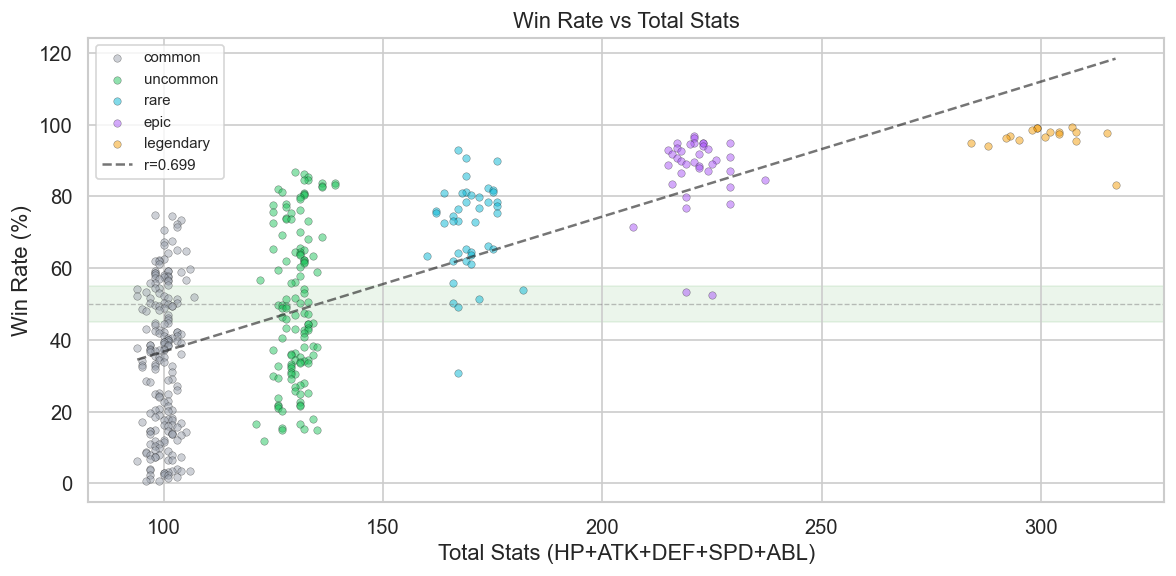

Pearson r = 0.699 (p=4.89e-62)
  ℹ Moderate correlation — abilities/synergies matter significantly


In [5]:
# Win rate vs total stats scatter
fig, ax = plt.subplots(figsize=(10, 5))
for rarity in RARITY_ORDER:
    subset = matchup[matchup['rarity'] == rarity]
    ax.scatter(subset['total_stats'], subset['win_rate'],
              c=RARITY_COLORS[rarity], label=rarity, alpha=0.5, s=20, edgecolors='k', linewidth=0.3)

# Regression line
slope, intercept, r, p, se = stats.linregress(matchup['total_stats'], matchup['win_rate'])
x_line = np.linspace(matchup['total_stats'].min(), matchup['total_stats'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5, alpha=0.6,
        label=f'r={r:.3f}')

balance_band(ax)
ax.set_xlabel('Total Stats (HP+ATK+DEF+SPD+ABL)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate vs Total Stats')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Pearson r = {r:.3f} (p={p:.2e})')
if r > 0.95:
    print('  ⚠ Very high correlation — game may be too stat-check-y')
elif r < 0.7:
    print('  ℹ Moderate correlation — abilities/synergies matter significantly')

---
## 2. Role Effectiveness Matrix

A healthy role system has circular dominance (rock-paper-scissors-like). No role should dominate all others.

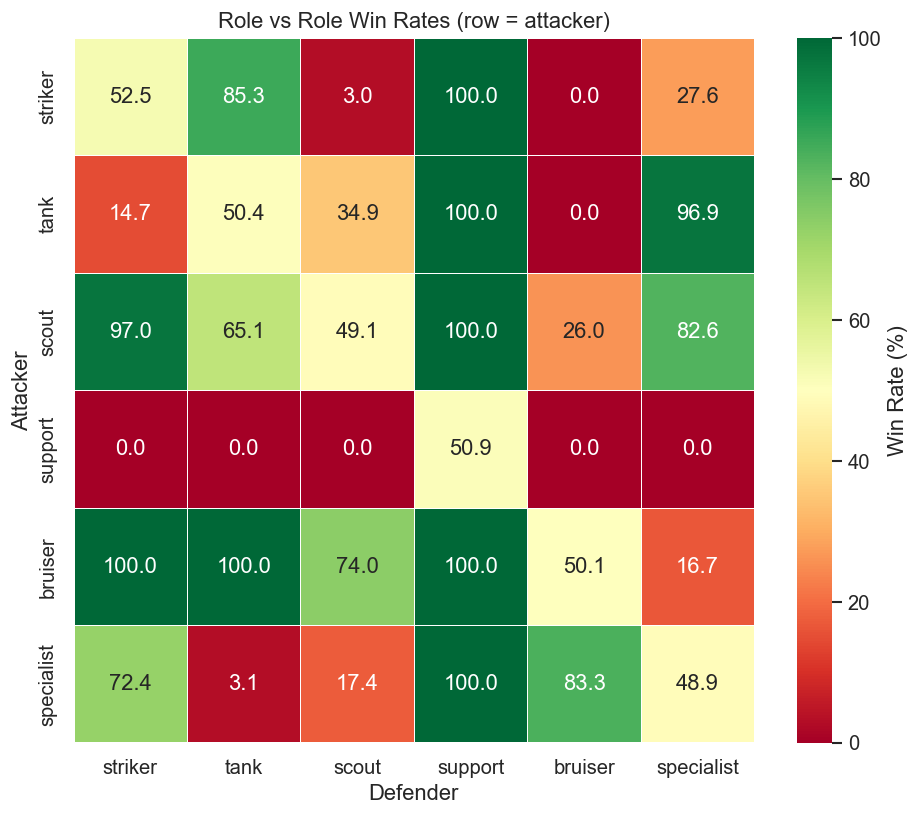

In [6]:
# 6x6 role heatmap
role_matrix = role.pivot(index='attacker_role', columns='defender_role', values='win_rate')
role_matrix = role_matrix.reindex(index=ROLE_ORDER, columns=ROLE_ORDER)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(role_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Win Rate (%)'})
ax.set_title('Role vs Role Win Rates (row = attacker)')
ax.set_ylabel('Attacker')
ax.set_xlabel('Defender')
plt.tight_layout()
plt.show()

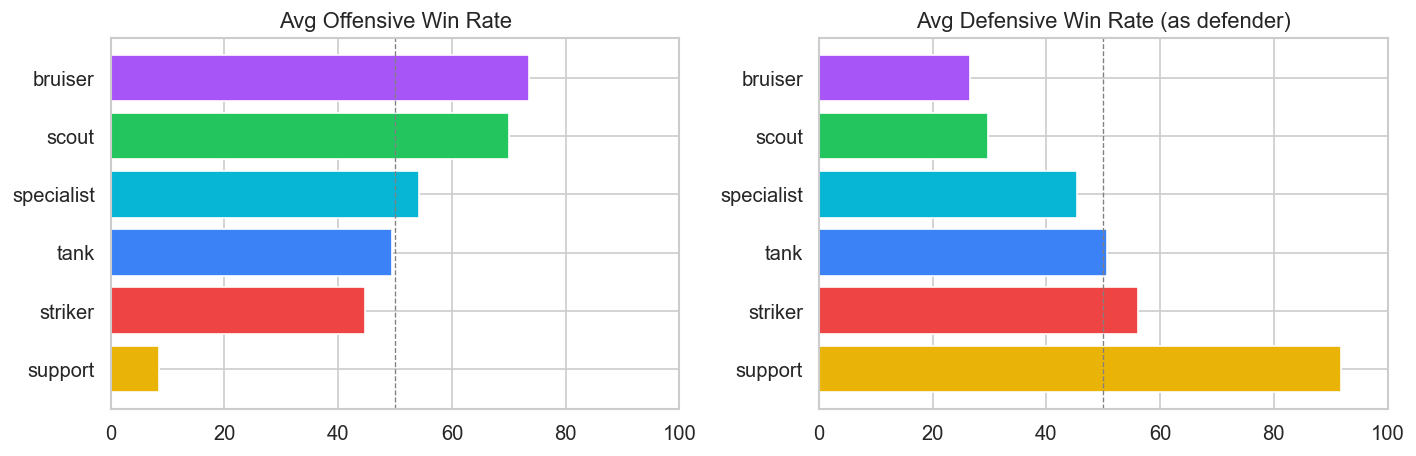

ROLE BALANCE ALERTS:
  ⚠ scout avg offensive WR 70.0% — overpowered
  ⚠ support avg offensive WR 8.5% — underpowered
  ⚠ bruiser avg offensive WR 73.5% — overpowered


In [7]:
# Per-role average offensive/defensive win rates
atk_avg = role_matrix.mean(axis=1).sort_values(ascending=True)
def_avg = (100 - role_matrix.mean(axis=0)).sort_values(ascending=True)  # defensive = how often opponents lose

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [ROLE_COLORS.get(r, '#888') for r in atk_avg.index]
axes[0].barh(atk_avg.index, atk_avg.values, color=colors)
axes[0].axvline(50, color='gray', ls='--', lw=0.8)
axes[0].set_title('Avg Offensive Win Rate')
axes[0].set_xlim(0, 100)

colors2 = [ROLE_COLORS.get(r, '#888') for r in def_avg.index]
axes[1].barh(def_avg.index, role_matrix.mean(axis=0).reindex(def_avg.index).values, color=colors2)
axes[1].axvline(50, color='gray', ls='--', lw=0.8)
axes[1].set_title('Avg Defensive Win Rate (as defender)')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

print('ROLE BALANCE ALERTS:')
for r in ROLE_ORDER:
    avg = role_matrix.loc[r].mean() if r in role_matrix.index else 50
    if avg > 65:
        print(f'  ⚠ {r} avg offensive WR {avg:.1f}% — overpowered')
    elif avg < 35:
        print(f'  ⚠ {r} avg offensive WR {avg:.1f}% — underpowered')

---
## 3. Creature Outliers

Within each rarity, creatures should have roughly similar power. Outliers need stat or ability tuning.

In [8]:
# Z-score outlier detection per rarity
matchup['z_score'] = matchup.groupby('rarity', observed=True)['win_rate'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
)

outliers = matchup[matchup['z_score'].abs() > 2].sort_values('z_score', ascending=False)
outlier_cols = ['name', 'rarity', 'role', 'win_rate', 'z_score', 'total_stats', 'active1', 'active2', 'passive']

print(f'OUTLIERS (|z| > 2): {len(outliers)} creatures')
print()
if len(outliers) > 0:
    overpowered = outliers[outliers['z_score'] > 0]
    underpowered = outliers[outliers['z_score'] < 0]
    if len(overpowered) > 0:
        print('OVERPOWERED:')
        display(overpowered[outlier_cols].reset_index(drop=True))
    if len(underpowered) > 0:
        print('\nUNDERPOWERED:')
        display(underpowered[outlier_cols].reset_index(drop=True))
else:
    print('  No outliers — intra-tier balance looks good')

OUTLIERS (|z| > 2): 5 creatures

OVERPOWERED:


,name,rarity,role,win_rate,z_score,total_stats,active1,active2,passive
0,Confuciusornis,common,scout,74.85,2.006805,98,dive_attack,claw_strike,aquatic_adaptation



UNDERPOWERED:


,name,rarity,role,win_rate,z_score,total_stats,active1,active2,passive
0,Rhabdodon,rare,support,30.71,-3.204592,167,mend,apex_roar,ancient_resilience
1,Pachycephalosaurus,epic,support,53.47,-3.335433,219,headbutt,intimidate,territorial
2,Yutyrannus,epic,bruiser,52.55,-3.426102,225,primal_surge,intimidate,thermal_regulation
3,Quetzalcoatlus,legendary,scout,83.20,-3.529181,317,dive_attack,intimidate,apex_predator


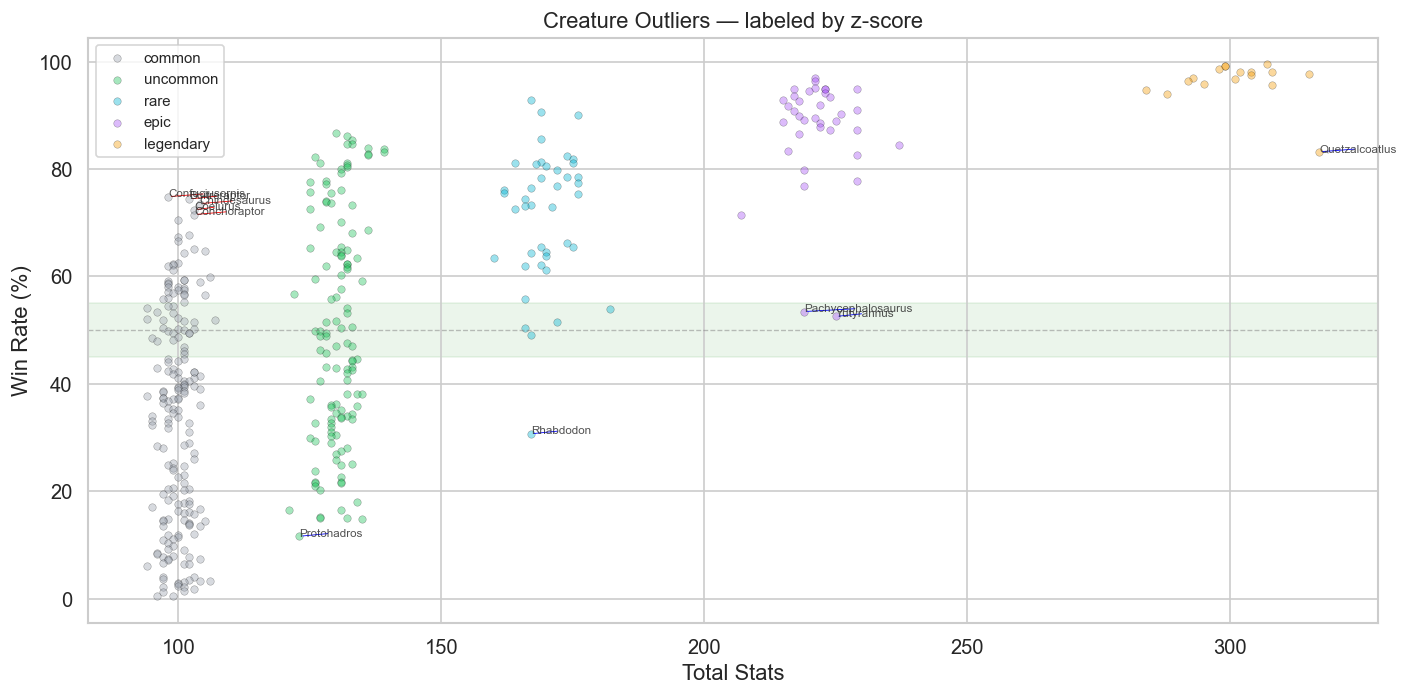

In [9]:
# Scatter with labeled outliers
fig, ax = plt.subplots(figsize=(12, 6))
for rarity in RARITY_ORDER:
    subset = matchup[matchup['rarity'] == rarity]
    ax.scatter(subset['total_stats'], subset['win_rate'],
              c=RARITY_COLORS[rarity], label=rarity, alpha=0.4, s=20, edgecolors='k', linewidth=0.3)

# Label top 5 and bottom 5 outliers
for _, row in matchup.nlargest(5, 'z_score').iterrows():
    ax.annotate(row['name'], (row['total_stats'], row['win_rate']),
               fontsize=7, alpha=0.8, ha='left',
               arrowprops=dict(arrowstyle='-', color='red', lw=0.5))
for _, row in matchup.nsmallest(5, 'z_score').iterrows():
    ax.annotate(row['name'], (row['total_stats'], row['win_rate']),
               fontsize=7, alpha=0.8, ha='left',
               arrowprops=dict(arrowstyle='-', color='blue', lw=0.5))

balance_band(ax)
ax.set_xlabel('Total Stats')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Creature Outliers — labeled by z-score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# Top 3 and bottom 3 per rarity
for rarity in RARITY_ORDER:
    subset = matchup[matchup['rarity'] == rarity].sort_values('win_rate', ascending=False)
    cols = ['name', 'role', 'win_rate', 'total_stats', 'active1', 'active2', 'passive']
    top = subset.head(3)[cols]
    bottom = subset.tail(3)[cols]
    print(f'\n--- {rarity.upper()} ---')
    print('Top 3:')
    display(top.reset_index(drop=True))
    print('Bottom 3:')
    display(bottom.reset_index(drop=True))


--- COMMON ---
Top 3:


,name,role,win_rate,total_stats,active1,active2,passive
0,Confuciusornis,scout,74.85,98,dive_attack,claw_strike,aquatic_adaptation
1,Buitreraptor,scout,74.42,102,dive_attack,bite,pack_hunter
2,Chindesaurus,scout,73.55,104,ambush,claw_strike,evasive


Bottom 3:


,name,role,win_rate,total_stats,active1,active2,passive
0,Othnielia,support,1.24,97,claw_strike,adrenaline_rush,evasive
1,Zephyrosaurus,support,0.56,99,graze,adrenaline_rush,evasive
2,Agilisaurus,support,0.54,96,adrenaline_rush,mend,herd_mentality



--- UNCOMMON ---
Top 3:


...

,name,role,win_rate,total_stats,active1,active2,passive
0,Ichthyosaurus,specialist,71.48,207,dive_attack,armor_break,aquatic_adaptation
1,Pachycephalosaurus,support,53.47,219,headbutt,intimidate,territorial
2,Yutyrannus,bruiser,52.55,225,primal_surge,intimidate,thermal_regulation



--- LEGENDARY ---
Top 3:


,name,role,win_rate,total_stats,active1,active2,passive
0,Titanoboa,scout,99.51,307,constrict,ambush,apex_predator
1,Protarchaeopteryx,scout,99.18,299,dive_attack,claw_strike,apex_predator
2,Archaeopteryx,scout,99.16,299,ambush,claw_strike,apex_predator


Bottom 3:


,name,role,win_rate,total_stats,active1,active2,passive
0,Anomalocaris,bruiser,94.80,284,tidal_wave,constrict,aquatic_adaptation
1,Brachiosaurus,tank,93.99,288,stomp,apex_roar,apex_predator
2,Quetzalcoatlus,scout,83.20,317,dive_attack,intimidate,apex_predator


---
## 4. Synergy Impact

Synergies should reward intentional team-building with a meaningful but not insurmountable edge (target: 52–58%).

| Synergy | Bonus |
|---------|-------|
| Type 2x | +10% HP |
| Type 3x | +15% HP, +10% ATK |
| Era 2x | +5% all stats |
| Era 3x | +10% all stats |
| All Carnivore | +15% ATK |
| All Herbivore | +20% DEF |
| Mixed Diet | +10% SPD |

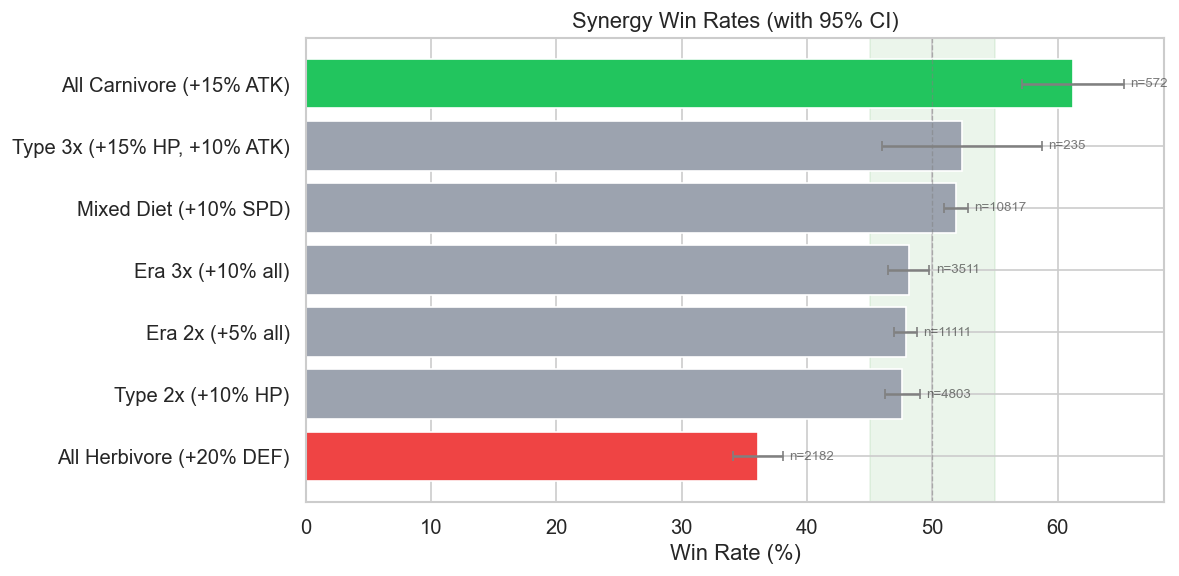

In [11]:
synergies = team[team['category'] == 'synergy'].copy()
synergies['delta'] = synergies['win_rate'] - 50
synergies = synergies.sort_values('win_rate', ascending=True)

# Wilson score 95% CI
z = 1.96
n = synergies['sample_size']
p = synergies['win_rate'] / 100
denom = 1 + z**2 / n
center = (p + z**2 / (2 * n)) / denom
margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
synergies['ci_lo'] = (center - margin) * 100
synergies['ci_hi'] = (center + margin) * 100
synergies['ci_err'] = synergies['win_rate'] - synergies['ci_lo']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#EF4444' if d < -3 else '#22C55E' if d > 3 else '#9CA3AF' for d in synergies['delta']]
ax.barh(synergies['name'], synergies['win_rate'], color=colors,
        xerr=synergies['ci_err'], capsize=3, ecolor='gray')
balance_band_h(ax)

# Annotate sample sizes
for i, (_, row) in enumerate(synergies.iterrows()):
    ax.text(row['win_rate'] + row['ci_err'] + 0.5, i, f'n={int(row["sample_size"])}',
            va='center', fontsize=8, alpha=0.6)

ax.set_xlabel('Win Rate (%)')
ax.set_title('Synergy Win Rates (with 95% CI)')
plt.tight_layout()
plt.show()

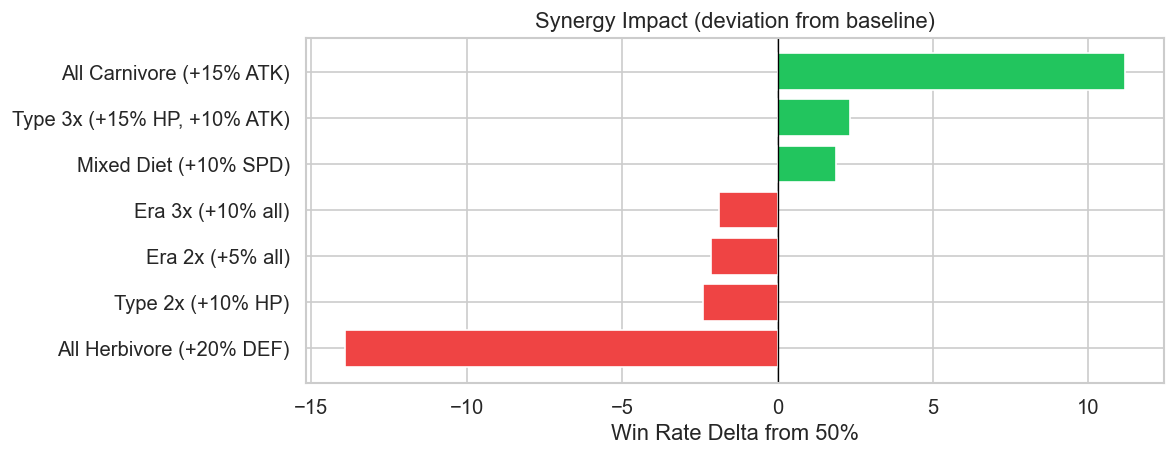

In [12]:
# Synergy delta from 50% (diverging bar)
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#EF4444' if d < 0 else '#22C55E' for d in synergies['delta']]
ax.barh(synergies['name'], synergies['delta'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Win Rate Delta from 50%')
ax.set_title('Synergy Impact (deviation from baseline)')
plt.tight_layout()
plt.show()

---
## 5. Ability Balance

Win rates measure correlation, not causation — a high-WR ability may be assigned to strong creatures. Still, large deviations suggest the ability itself is impactful.

In [13]:
ABILITY_CATEGORY_MAP = {
    'bite': 'damage', 'claw_strike': 'damage', 'horn_charge': 'damage',
    'crushing_jaw': 'damage', 'venom_strike': 'damage', 'feeding_frenzy': 'damage',
    'dive_attack': 'damage', 'ambush': 'damage', 'body_slam': 'damage',
    'leech_bite': 'damage', 'constrict': 'damage',
    'tail_sweep': 'aoe_damage', 'stomp': 'aoe_damage', 'screech': 'aoe_damage',
    'tidal_wave': 'aoe_damage', 'tremor': 'aoe_damage',
    'rally_cry': 'buff', 'herd_formation': 'buff', 'adrenaline_rush': 'buff',
    'apex_roar': 'buff', 'primal_surge': 'buff', 'fortify': 'buff', 'counter_stance': 'buff',
    'intimidate': 'debuff', 'mudslide': 'debuff', 'armor_break': 'debuff', 'spore_cloud': 'debuff',
    'graze': 'heal', 'symbiosis': 'heal', 'regenerate': 'heal', 'mend': 'heal',
    'shell_guard': 'shield', 'headbutt': 'stun', 'taunt': 'taunt', 'bleed': 'dot',
}

CATEGORY_COLORS = {
    'damage': '#EF4444', 'aoe_damage': '#F97316', 'buff': '#22C55E',
    'debuff': '#A855F7', 'heal': '#3B82F6', 'shield': '#06B6D4',
    'stun': '#EC4899', 'taunt': '#6B7280', 'dot': '#92400E',
}

active = ability[ability['type'] == 'active'].copy().sort_values('win_rate', ascending=True)
passive = ability[ability['type'] == 'passive'].copy().sort_values('win_rate', ascending=True)
active['category'] = active['id'].map(ABILITY_CATEGORY_MAP).fillna('other')

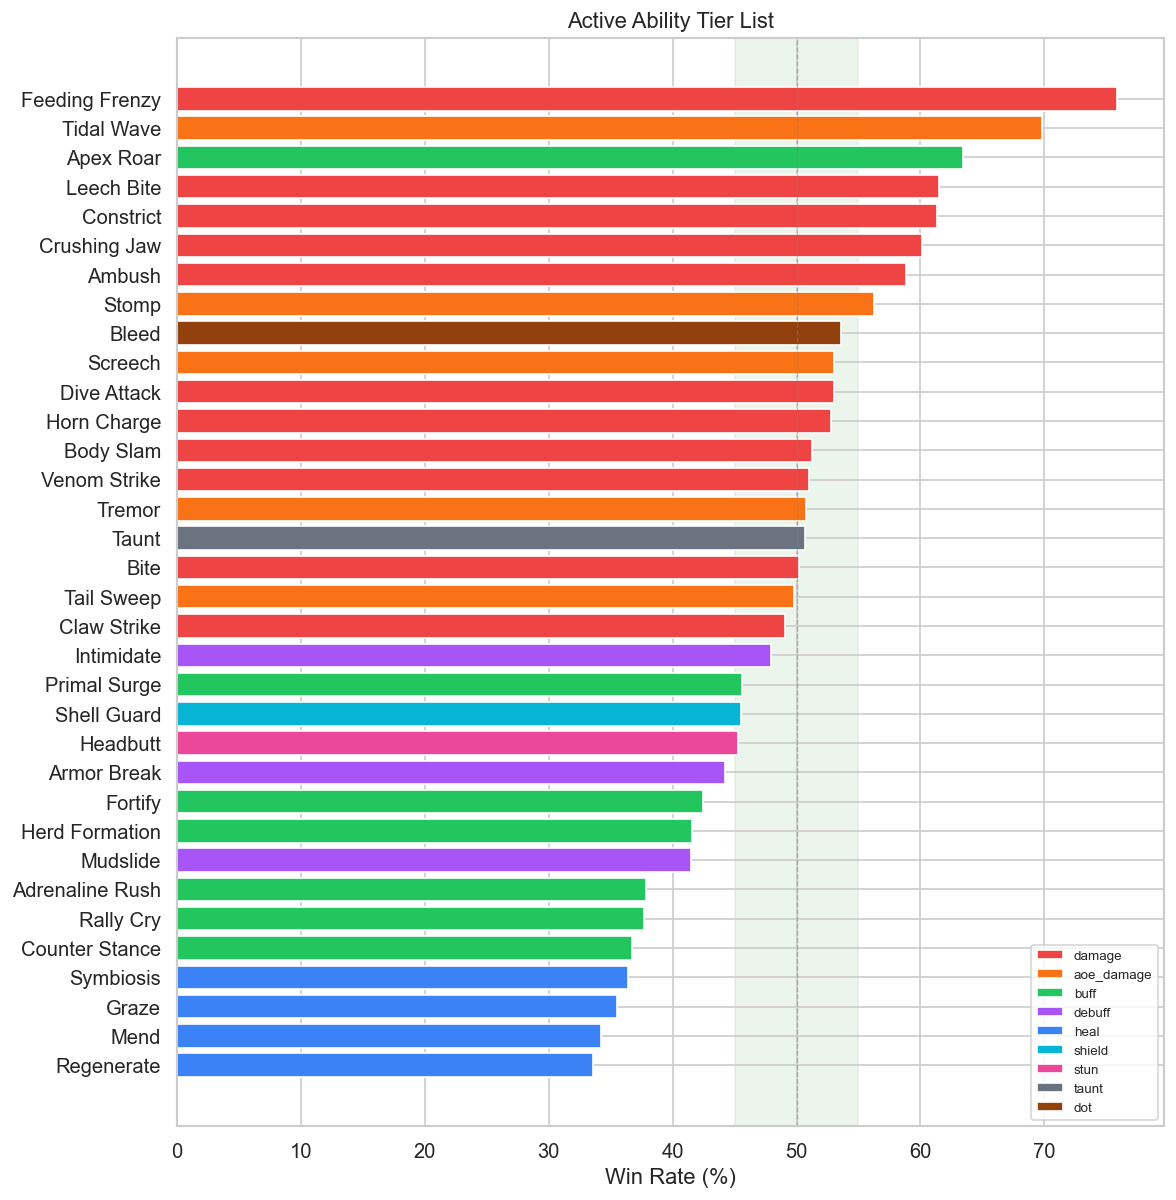

In [14]:
# Active ability tier list
fig, ax = plt.subplots(figsize=(10, max(6, len(active) * 0.3)))
colors = [CATEGORY_COLORS.get(c, '#888') for c in active['category']]
ax.barh(active['name'], active['win_rate'], color=colors)
balance_band_h(ax)
ax.set_xlabel('Win Rate (%)')
ax.set_title('Active Ability Tier List')

# Legend for categories
from matplotlib.patches import Patch
legend_items = [Patch(facecolor=c, label=cat) for cat, c in CATEGORY_COLORS.items()
                if cat in active['category'].values]
ax.legend(handles=legend_items, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

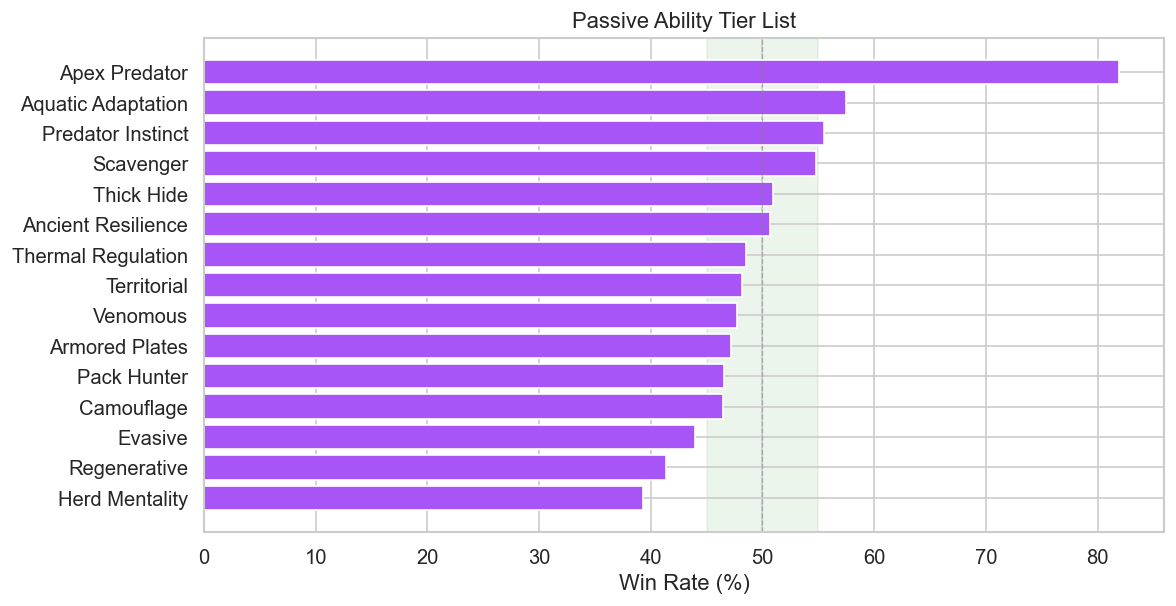

In [15]:
# Passive ability tier list
fig, ax = plt.subplots(figsize=(10, max(4, len(passive) * 0.35)))
ax.barh(passive['name'], passive['win_rate'], color='#A855F7')
balance_band_h(ax)
ax.set_xlabel('Win Rate (%)')
ax.set_title('Passive Ability Tier List')
plt.tight_layout()
plt.show()

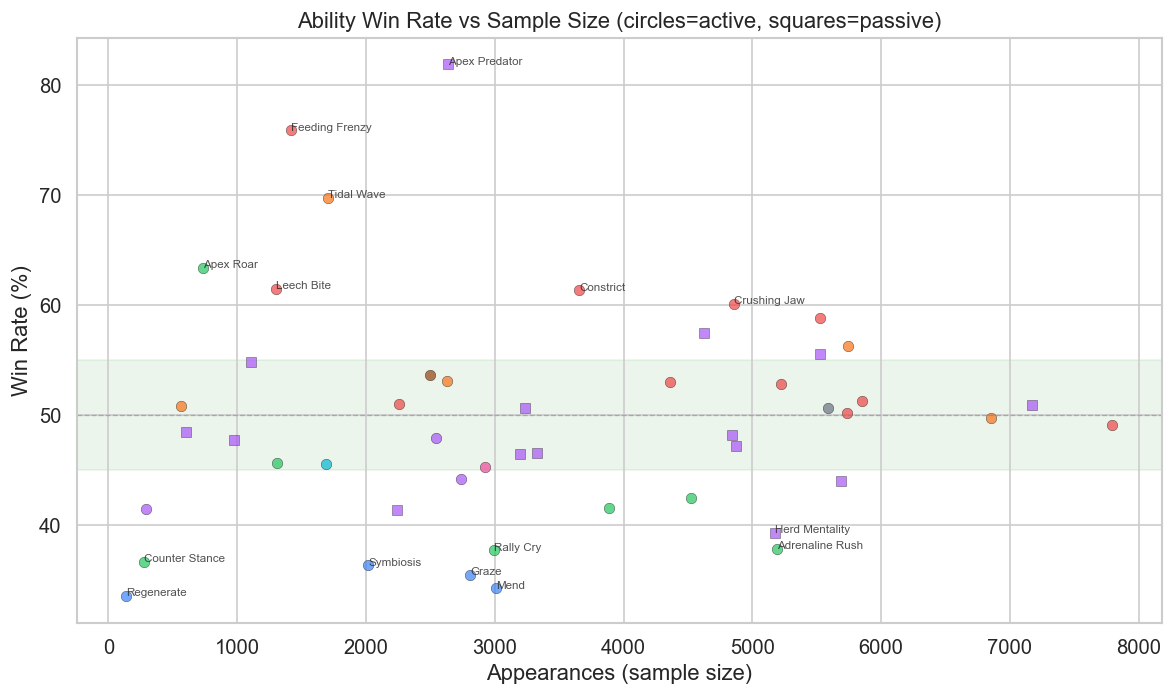

In [16]:
# Ability win rate vs appearances (statistical significance)
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in active.iterrows():
    ax.scatter(row['appearances'], row['win_rate'], s=40,
              c=CATEGORY_COLORS.get(row['category'], '#888'),
              edgecolors='k', linewidth=0.3, alpha=0.7)
    if abs(row['win_rate'] - 50) > 10:
        ax.annotate(row['name'], (row['appearances'], row['win_rate']),
                   fontsize=7, alpha=0.8)

for _, row in passive.iterrows():
    ax.scatter(row['appearances'], row['win_rate'], s=40,
              c='#A855F7', marker='s', edgecolors='k', linewidth=0.3, alpha=0.7)
    if abs(row['win_rate'] - 50) > 10:
        ax.annotate(row['name'], (row['appearances'], row['win_rate']),
                   fontsize=7, alpha=0.8)

balance_band(ax)
ax.set_xlabel('Appearances (sample size)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Ability Win Rate vs Sample Size (circles=active, squares=passive)')
plt.tight_layout()
plt.show()

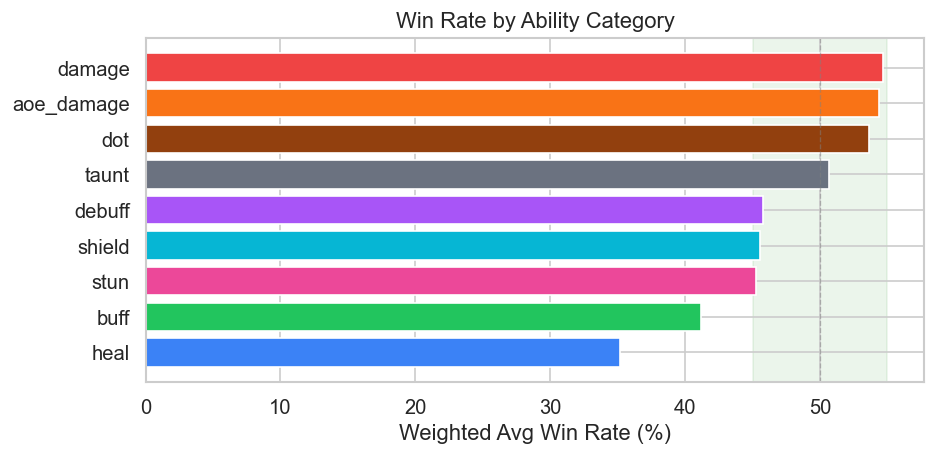

In [17]:
# Ability category summary
cat_summary = active.groupby('category').apply(
    lambda g: np.average(g['win_rate'], weights=g['appearances'])
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = [CATEGORY_COLORS.get(c, '#888') for c in cat_summary.index]
ax.barh(cat_summary.index, cat_summary.values, color=colors)
balance_band_h(ax)
ax.set_xlabel('Weighted Avg Win Rate (%)')
ax.set_title('Win Rate by Ability Category')
plt.tight_layout()
plt.show()

---
## 6. Team Composition Meta

Which role combinations produce the strongest teams? A healthy meta has multiple viable compositions.

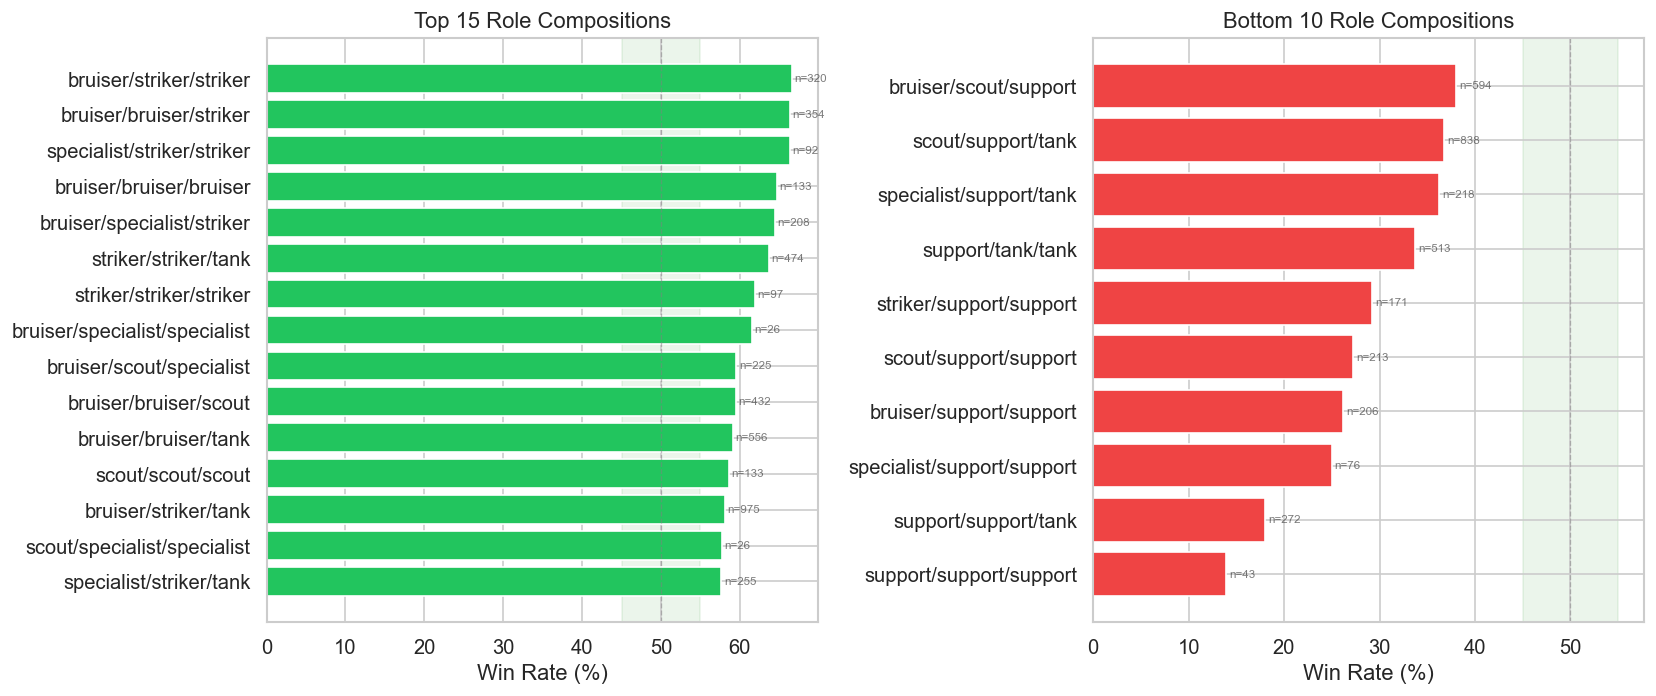

In [18]:
combos = team[team['category'] == 'role_combo'].copy()
combos = combos.sort_values('win_rate', ascending=True)

# Top 15 and bottom 10
top_combos = combos.tail(15)
bot_combos = combos.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_top = ['#22C55E' if wr > 55 else '#EAB308' if wr > 45 else '#EF4444' for wr in top_combos['win_rate']]
axes[0].barh(top_combos['name'], top_combos['win_rate'], color=colors_top)
balance_band_h(axes[0])
axes[0].set_xlabel('Win Rate (%)')
axes[0].set_title('Top 15 Role Compositions')
for i, (_, row) in enumerate(top_combos.iterrows()):
    axes[0].text(row['win_rate'] + 0.3, i, f'n={int(row["sample_size"])}', va='center', fontsize=7, alpha=0.6)

colors_bot = ['#EF4444' if wr < 45 else '#EAB308' if wr < 55 else '#22C55E' for wr in bot_combos['win_rate']]
axes[1].barh(bot_combos['name'], bot_combos['win_rate'], color=colors_bot)
balance_band_h(axes[1])
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_title('Bottom 10 Role Compositions')
for i, (_, row) in enumerate(bot_combos.iterrows()):
    axes[1].text(row['win_rate'] + 0.3, i, f'n={int(row["sample_size"])}', va='center', fontsize=7, alpha=0.6)

plt.tight_layout()
plt.show()

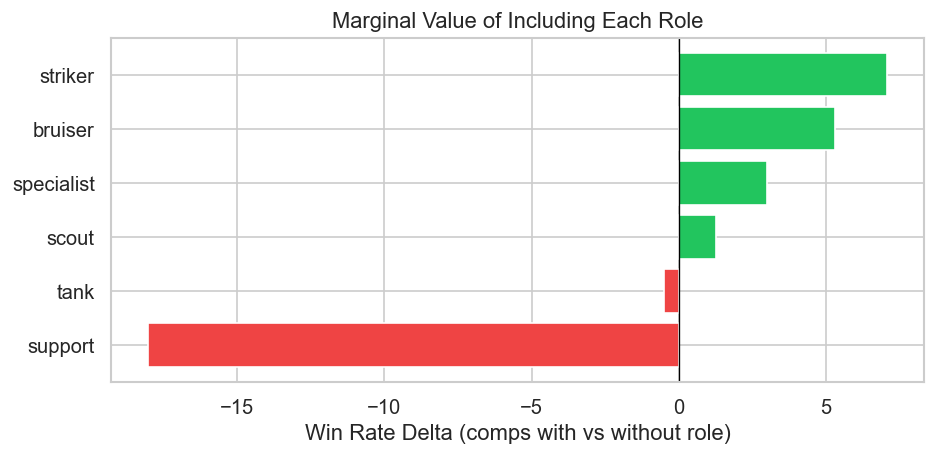

In [19]:
# Role presence marginal value
role_presence = {}
for r in ROLE_ORDER:
    with_role = combos[combos['name'].str.contains(r)]
    without_role = combos[~combos['name'].str.contains(r)]
    if len(with_role) > 0 and len(without_role) > 0:
        avg_with = np.average(with_role['win_rate'], weights=with_role['sample_size'])
        avg_without = np.average(without_role['win_rate'], weights=without_role['sample_size'])
        role_presence[r] = avg_with - avg_without

rp = pd.Series(role_presence).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#EF4444' if v < 0 else '#22C55E' for v in rp.values]
ax.barh(rp.index, rp.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Win Rate Delta (comps with vs without role)')
ax.set_title('Marginal Value of Including Each Role')
plt.tight_layout()
plt.show()

---
## 7. Stat Correlations & Balance Summary

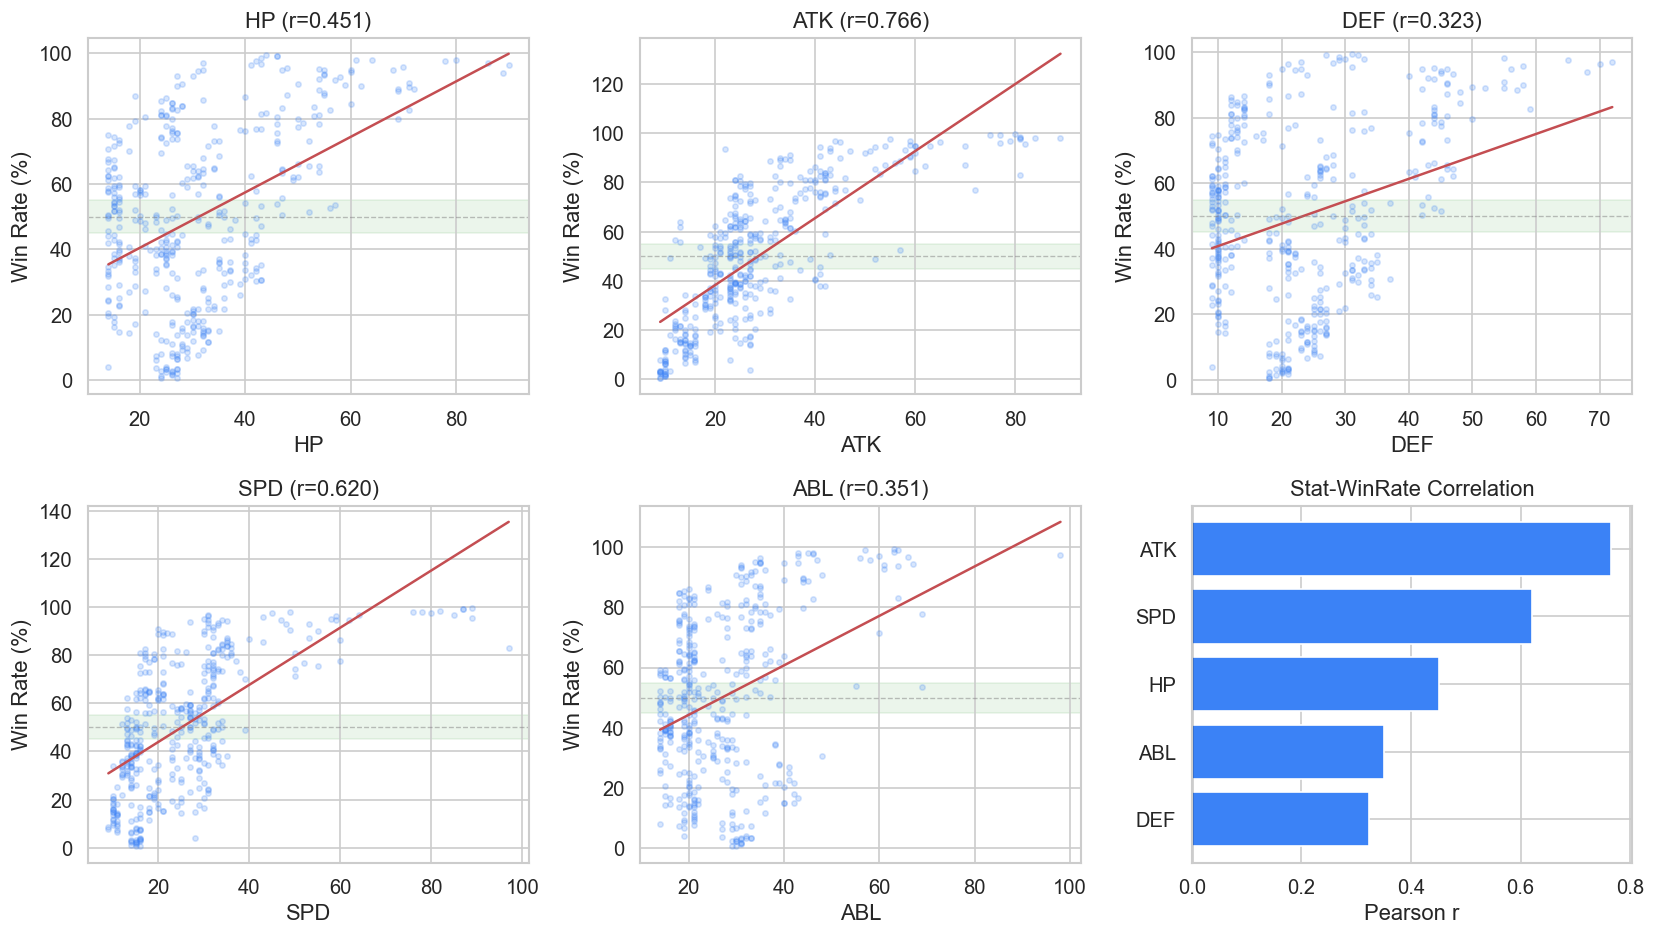

In [20]:
# Stat correlation with win rate
stat_cols = ['hp', 'atk', 'def', 'spd', 'abl']
corrs = matchup[stat_cols + ['win_rate']].corr()['win_rate'].drop('win_rate')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, stat in enumerate(stat_cols):
    ax = axes[i]
    ax.scatter(matchup[stat], matchup['win_rate'], alpha=0.2, s=10, c='#3B82F6')
    slope, intercept, r, p, se = stats.linregress(matchup[stat], matchup['win_rate'])
    x = np.linspace(matchup[stat].min(), matchup[stat].max(), 100)
    ax.plot(x, slope * x + intercept, 'r-', lw=1.5)
    ax.set_title(f'{stat.upper()} (r={r:.3f})')
    ax.set_xlabel(stat.upper())
    ax.set_ylabel('Win Rate (%)')
    balance_band(ax)

# Correlation bar chart in the 6th subplot
ax = axes[5]
corrs_sorted = corrs.sort_values()
colors = ['#EF4444' if v < 0 else '#3B82F6' for v in corrs_sorted.values]
ax.barh(corrs_sorted.index.str.upper(), corrs_sorted.values, color=colors)
ax.set_title('Stat-WinRate Correlation')
ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

In [21]:
# ═══ BALANCE REPORT CARD ═══
print('=' * 60)
print('BALANCE REPORT CARD')
print('=' * 60)
print()

# Rarity
r_means = matchup.groupby('rarity', observed=True)['win_rate'].mean()
gap = r_means.get('legendary', 50) - r_means.get('common', 50)
rarity_grade = 'OK' if gap < 50 else 'NEEDS WORK' if gap < 70 else 'CRITICAL'
print(f'Rarity Power Curve:  {rarity_grade}')
print(f'  Legendary avg: {r_means.get("legendary", 0):.1f}%, Common avg: {r_means.get("common", 0):.1f}% (gap: {gap:.1f}pp)')
print()

# Roles
role_avgs = role_matrix.mean(axis=1)
role_spread = role_avgs.max() - role_avgs.min()
role_grade = 'OK' if role_spread < 20 else 'NEEDS WORK' if role_spread < 40 else 'CRITICAL'
print(f'Role Balance:        {role_grade}')
for r in ROLE_ORDER:
    if r in role_avgs.index:
        avg = role_avgs[r]
        flag = ' ⚠ HIGH' if avg > 60 else ' ⚠ LOW' if avg < 40 else ''
        print(f'  {r}: {avg:.1f}%{flag}')
print()

# Outliers
n_outliers = len(outliers)
print(f'Creature Outliers:   {n_outliers} flagged (|z| > 2)')
n_op = len(outliers[outliers['z_score'] > 0])
n_up = len(outliers[outliers['z_score'] < 0])
print(f'  {n_op} overpowered, {n_up} underpowered')
print()

# Synergies
syn_deltas = synergies['delta'].abs()
syn_grade = 'OK' if syn_deltas.max() < 8 else 'NEEDS WORK' if syn_deltas.max() < 15 else 'CRITICAL'
print(f'Synergy Balance:     {syn_grade}')
for _, row in synergies.iterrows():
    flag = ' ⚠' if abs(row['delta']) > 5 else ''
    print(f'  {row["name"]}: {row["win_rate"]:.1f}%{flag}')
print()

# Abilities
all_ab = pd.concat([active, passive])
ab_extreme = all_ab[(all_ab['win_rate'] > 60) | (all_ab['win_rate'] < 40)]
ab_grade = 'OK' if len(ab_extreme) < 3 else 'NEEDS WORK' if len(ab_extreme) < 8 else 'CRITICAL'
print(f'Ability Balance:     {ab_grade}')
if len(ab_extreme) > 0:
    for _, row in ab_extreme.sort_values('win_rate', ascending=False).iterrows():
        direction = '↑' if row['win_rate'] > 55 else '↓'
        print(f'  {direction} {row["name"]} ({row["type"]}): {row["win_rate"]:.1f}%')
print()

# Team diversity
viable = combos[(combos['win_rate'] >= 45) & (combos['win_rate'] <= 55)]
div_grade = 'OK' if len(viable) > 15 else 'NEEDS WORK' if len(viable) > 5 else 'CRITICAL'
print(f'Team Comp Diversity: {div_grade}')
print(f'  {len(viable)} / {len(combos)} comps in the 45-55% band')
print()
print('=' * 60)

BALANCE REPORT CARD

Rarity Power Curve:  NEEDS WORK
  Legendary avg: 96.4%, Common avg: 34.1% (gap: 62.4pp)

Role Balance:        CRITICAL
  striker: 44.7%
  tank: 49.5%
  scout: 70.0% ⚠ HIGH
  support: 8.5% ⚠ LOW
  bruiser: 73.5% ⚠ HIGH
  specialist: 54.2%

Creature Outliers:   5 flagged (|z| > 2)
  1 overpowered, 4 underpowered

Synergy Balance:     NEEDS WORK
  All Herbivore (+20% DEF): 36.1% ⚠
  Type 2x (+10% HP): 47.6%
  Era 2x (+5% all): 47.9%
  Era 3x (+10% all): 48.1%
  Mixed Diet (+10% SPD): 51.9%
  Type 3x (+15% HP, +10% ATK): 52.3%
  All Carnivore (+15% ATK): 61.2% ⚠

Ability Balance:     CRITICAL
  ↑ Apex Predator (passive): 81.9%
  ↑ Feeding Frenzy (active): 75.9%
  ↑ Tidal Wave (active): 69.8%
  ↑ Apex Roar (active): 63.4%
  ↑ Leech Bite (active): 61.5%
  ↑ Constrict (active): 61.4%
  ↑ Crushing Jaw (active): 60.1%
  ↓ Herd Mentality (passive): 39.3%
  ↓ Adrenaline Rush (active): 37.8%
  ↓ Rally Cry (active): 37.7%
  ↓ Counter Stance (active): 36.7%
  ↓ Symbiosis (active